# 特征贡献分析与评分规则优化

## 一、环境配置与数据加载

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# 中文字体设置
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 路径配置
processed_path = '../data/processed/'
fig_save_path = '../results/figures/'
os.makedirs(fig_save_path, exist_ok=True)

### 1.1 加载数据并还原原始特征

In [3]:
# 加载标准化后的测试集与标签
X_test_std = np.load(os.path.join(processed_path, 'X_test.npy'))
test_type_labels = np.load(os.path.join(processed_path, 'test_type_labels.npy'))

# 加载标准化器，逆变换得到原始特征值（与评分计算输入一致）
scaler_final = joblib.load(os.path.join(processed_path, 'scaler_final.pkl'))
X_test_raw = scaler_final.inverse_transform(X_test_std)

# 23维特征名称（与特征提取顺序严格一一对应）
feature_names = [
    'avg_speed', 'max_speed', 'std_speed', 'speed_cv',
    'avg_dir_change', 'max_dir_change', 'std_dir_change',
    'avg_facing_deviation', 'max_facing_deviation',
    'path_length', 'start_end_dist', 'tortuosity',
    'low_speed_ratio', 'duration',
    'center_x', 'center_y',
    'max_acceleration', 'std_acceleration',
    'turn_frequency', 'angle_entropy', 'direction_reversal_rate',
    'min_dist_to_forbidden', 'in_forbidden_ratio'
]

print(f"测试集形状: {X_test_raw.shape}")
print(f"特征维度数: {len(feature_names)}")

测试集形状: (50082, 23)
特征维度数: 23


### 1.2 按异常类别拆分样本

In [4]:
# 各类别掩码
mask_normal = test_type_labels == 0
mask_running = test_type_labels == 1
mask_loitering = test_type_labels == 2
mask_trespassing = test_type_labels == 3

# 拆分原始特征
X_normal = X_test_raw[mask_normal]
X_running = X_test_raw[mask_running]
X_loitering = X_test_raw[mask_loitering]
X_trespassing = X_test_raw[mask_trespassing]

print(f"样本分布：")
print(f"  正常样本：{len(X_normal)} 条")
print(f"  奔跑异常：{len(X_running)} 条")
print(f"  徘徊异常：{len(X_loitering)} 条")
print(f"  闯入禁区：{len(X_trespassing)} 条")

样本分布：
  正常样本：25041 条
  奔跑异常：8347 条
  徘徊异常：8347 条
  闯入禁区：8347 条


## 二、特征分布差异定性分析

### 2.1 各类别特征均值对比

In [5]:
# 生成四类样本的特征均值对比表
mean_comparison = pd.DataFrame({
    '正常样本': X_normal.mean(axis=0),
    '奔跑异常': X_running.mean(axis=0),
    '徘徊异常': X_loitering.mean(axis=0),
    '闯入禁区': X_trespassing.mean(axis=0)
}, index=feature_names)

print("各类别特征均值对比：")
display(mean_comparison.round(2))

各类别特征均值对比：


,正常样本,奔跑异常,徘徊异常,闯入禁区
avg_speed,923.40,2590.40,302.21,918.30
max_speed,1661.37,10054.17,1592.60,1652.99
std_speed,230.93,2600.81,316.45,229.79
speed_cv,0.26,1.00,1.11,0.26
avg_dir_change,0.05,0.05,0.11,0.05
max_dir_change,1.03,1.04,3.05,1.03
std_dir_change,0.09,0.09,0.39,0.09
avg_facing_deviation,0.08,0.08,0.08,0.08
max_facing_deviation,1.05,1.05,1.04,1.05
path_length,37668.65,37958.04,136214.23,37802.16


### 2.2 核心特征分布箱线图

#### （1）奔跑异常核心特征对比

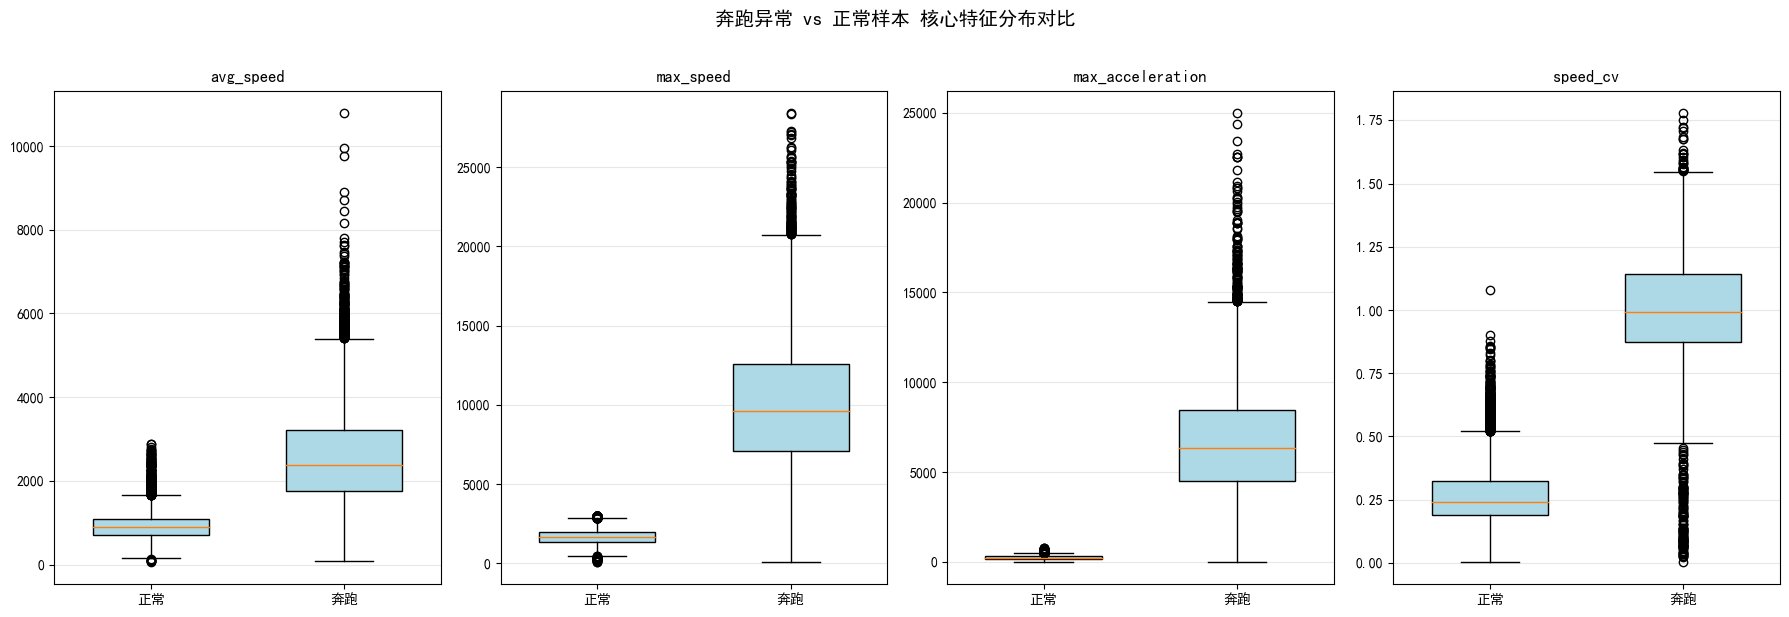

In [6]:
plot_feats_run = ['avg_speed', 'max_speed', 'max_acceleration', 'speed_cv']
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for i, feat in enumerate(plot_feats_run):
    idx = feature_names.index(feat)
    data = [X_normal[:, idx], X_running[:, idx]]
    axes[i].boxplot(data, labels=['正常', '奔跑'], widths=0.6, patch_artist=True,
                    boxprops={'facecolor': 'lightblue'})
    axes[i].set_title(feat, fontsize=12)
    axes[i].grid(alpha=0.3, axis='y')

plt.suptitle('奔跑异常 vs 正常样本 核心特征分布对比', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(fig_save_path, 'running_feature_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

#### （2）徘徊异常核心特征对比

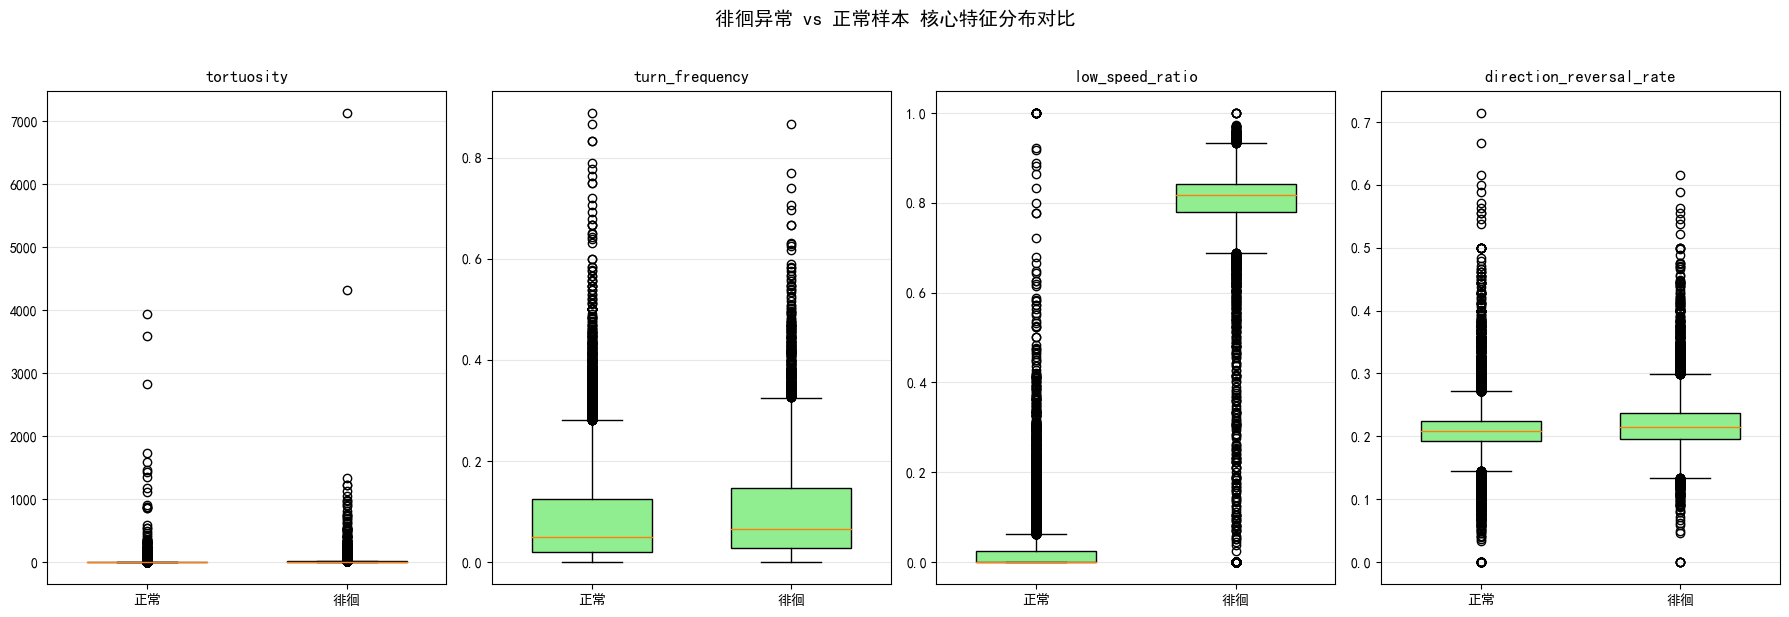

In [7]:
plot_feats_loit = ['tortuosity', 'turn_frequency', 'low_speed_ratio', 'direction_reversal_rate']
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for i, feat in enumerate(plot_feats_loit):
    idx = feature_names.index(feat)
    data = [X_normal[:, idx], X_loitering[:, idx]]
    axes[i].boxplot(data, labels=['正常', '徘徊'], widths=0.6, patch_artist=True,
                    boxprops={'facecolor': 'lightgreen'})
    axes[i].set_title(feat, fontsize=12)
    axes[i].grid(alpha=0.3, axis='y')

plt.suptitle('徘徊异常 vs 正常样本 核心特征分布对比', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(fig_save_path, 'loitering_feature_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

#### （3）闯入禁区核心特征对比

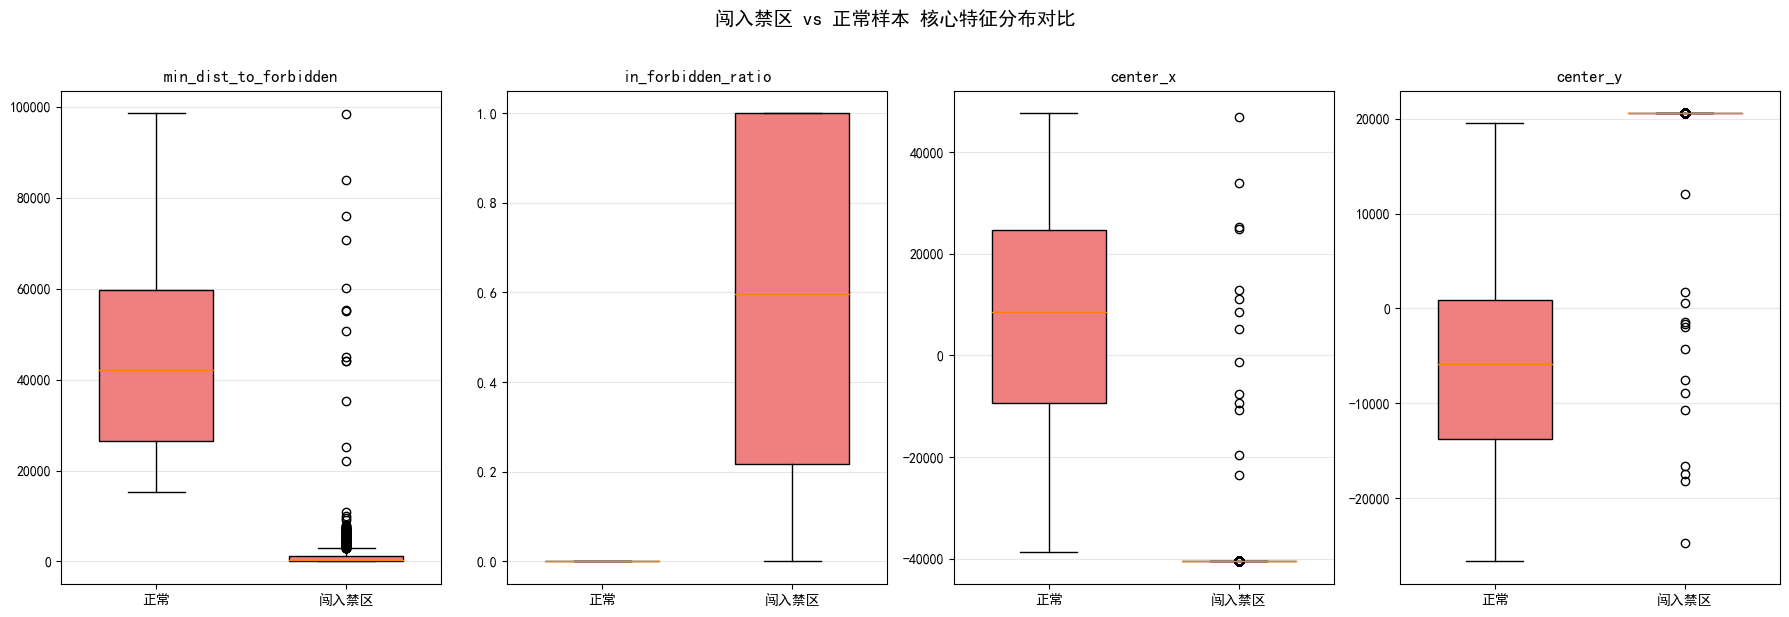

In [8]:
plot_feats_tresp = ['min_dist_to_forbidden', 'in_forbidden_ratio', 'center_x', 'center_y']
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for i, feat in enumerate(plot_feats_tresp):
    idx = feature_names.index(feat)
    data = [X_normal[:, idx], X_trespassing[:, idx]]
    axes[i].boxplot(data, labels=['正常', '闯入禁区'], widths=0.6, patch_artist=True,
                    boxprops={'facecolor': 'lightcoral'})
    axes[i].set_title(feat, fontsize=12)
    axes[i].grid(alpha=0.3, axis='y')

plt.suptitle('闯入禁区 vs 正常样本 核心特征分布对比', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(fig_save_path, 'trespassing_feature_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()

## 三、单特征区分度量化（单特征 AUC 法）

### 3.1 计算函数实现

In [9]:
def calc_single_feature_auc(X_normal, X_anomaly, feature_names):
    """
    计算每个特征单独区分正常/异常的AUC与方向
    返回：DataFrame包含特征名、AUC、方向（1=越大越异常，-1=越小越异常）
    """
    n_feat = X_normal.shape[1]
    auc_list = []
    direction_list = []
    
    # 构造标签
    y = np.concatenate([np.zeros(len(X_normal)), np.ones(len(X_anomaly))])
    
    for i in range(n_feat):
        feat_vals = np.concatenate([X_normal[:, i], X_anomaly[:, i]])
        auc = roc_auc_score(y, feat_vals)
        
        if auc < 0.5:
            auc_list.append(1 - auc)
            direction_list.append(-1)
        else:
            auc_list.append(auc)
            direction_list.append(1)
    
    result_df = pd.DataFrame({
        '特征名': feature_names,
        '单特征AUC': auc_list,
        '方向': direction_list
    }).sort_values('单特征AUC', ascending=False).reset_index(drop=True)
    
    return result_df

### 3.2 三类异常分别计算

In [10]:
# 奔跑异常
running_auc_df = calc_single_feature_auc(X_normal, X_running, feature_names)
# 徘徊异常
loitering_auc_df = calc_single_feature_auc(X_normal, X_loitering, feature_names)
# 闯入禁区
trespassing_auc_df = calc_single_feature_auc(X_normal, X_trespassing, feature_names)

In [11]:
print("="*60)
print("【奔跑异常】单特征区分度排名（Top10）")
print("="*60)
display(running_auc_df.head(10).round(4))

print("\n" + "="*60)
print("【徘徊异常】单特征区分度排名（Top10）")
print("="*60)
display(loitering_auc_df.head(10).round(4))

print("\n" + "="*60)
print("【闯入禁区】单特征区分度排名（Top10）")
print("="*60)
display(trespassing_auc_df.head(10).round(4))

【奔跑异常】单特征区分度排名（Top10）


,特征名,单特征AUC,方向
0,std_acceleration,0.9897,1
1,speed_cv,0.9892,1
2,std_speed,0.9864,1
3,max_acceleration,0.9861,1
4,max_speed,0.9858,1
5,avg_speed,0.9612,1
6,low_speed_ratio,0.5281,-1
7,angle_entropy,0.5021,-1
8,min_dist_to_forbidden,0.5015,1
9,max_dir_change,0.5014,1



【徘徊异常】单特征区分度排名（Top10）


,特征名,单特征AUC,方向
0,avg_speed,0.9839,-1
1,low_speed_ratio,0.9803,1
2,speed_cv,0.9776,1
3,max_dir_change,0.9756,1
4,max_acceleration,0.9710,1
5,std_dir_change,0.9440,1
6,tortuosity,0.8537,1
7,avg_dir_change,0.7972,1
8,path_length,0.7762,1
9,std_speed,0.7675,1



【闯入禁区】单特征区分度排名（Top10）


,特征名,单特征AUC,方向
0,center_x,0.9992,-1
1,center_y,0.9991,1
2,min_dist_to_forbidden,0.9989,-1
3,in_forbidden_ratio,0.9923,1
4,max_speed,0.5051,-1
5,max_acceleration,0.5042,-1
6,avg_speed,0.5042,-1
7,std_acceleration,0.5034,-1
8,std_speed,0.5034,-1
9,low_speed_ratio,0.5027,1


## 四、特征冗余性与相关性分析

### 4.1 正常样本特征相关性矩阵

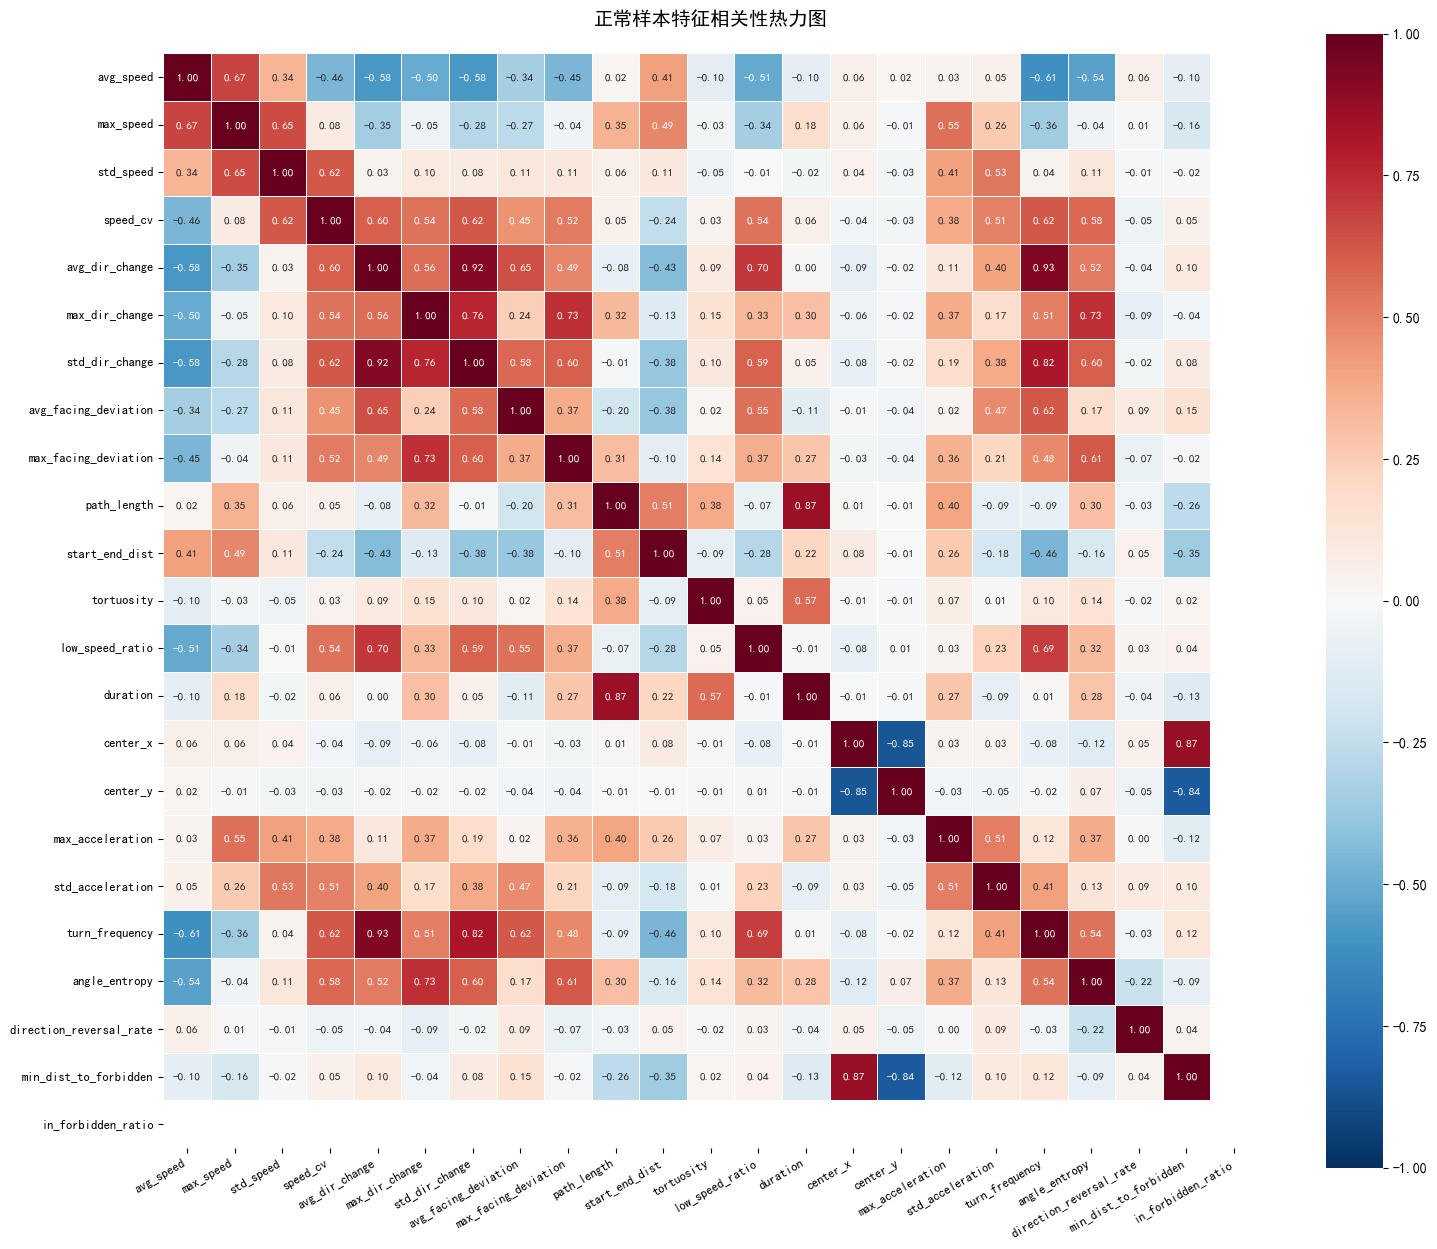

In [23]:
corr_matrix = pd.DataFrame(X_normal, columns=feature_names).corr()

# 绘制热力图
plt.figure(figsize=(18, 18))  # 改为严格正方形画布，完美适配square=True
ax = sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', 
    vmin=-1, 
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8}
)

# x轴标签旋转30度：比45度更省垂直空间，同时保持可读性
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.title('正常样本特征相关性热力图', fontsize=14, pad=20)

# 关键调整：加大底部、左侧边距，给长标签留足空间
plt.subplots_adjust(bottom=0.25, left=0.18, right=0.94)

plt.savefig(
    os.path.join(fig_save_path, 'feature_correlation_heatmap.png'), 
    dpi=150, 
    bbox_inches='tight'  # 保存时自动计算边界，导出文件一定完整
)
plt.show()

## 五、数据驱动的权重优化

### 5.1 权重计算函数

In [25]:
def optimize_feature_weights(
    auc_df, 
    corr_matrix, 
    auc_threshold=0.6, 
    redundancy_threshold=0.8,
    redundancy_penalty=0.3
):
    """
    基于「单特征AUC + 相关性去冗余」的数据驱动权重优化函数
    核心原则：
    1.  相关系数绝对值 > redundancy_threshold 视为高度冗余
    2.  优先保留单特征AUC更高、物理意义更直观的特征
    3.  对冗余特征施加权重折扣，避免单一维度过度主导评分

    参数：
    - auc_df: 单特征AUC结果表，需包含 特征名、单特征AUC、方向 三列
    - corr_matrix: 特征相关系数矩阵（DataFrame格式，索引与列均为特征名）
    - auc_threshold: 有效特征筛选阈值，AUC低于该值的特征直接剔除
    - redundancy_threshold: 高冗余判定阈值，默认0.8
    - redundancy_penalty: 冗余特征权重折扣系数，默认0.3（保留原权重的30%）

    返回：
    - DataFrame，包含特征名、单特征AUC、方向、是否冗余降权、最终优化权重
    """
    import numpy as np
    
    # ========== 步骤1：筛选有效特征，按AUC降序排序（优先级从高到低） ==========
    valid_df = auc_df[auc_df['单特征AUC'] > auc_threshold].copy()
    valid_df = valid_df.sort_values('单特征AUC', ascending=False).reset_index(drop=True)
    
    if len(valid_df) == 0:
        raise ValueError("没有符合AUC阈值的有效特征，请降低auc_threshold")

    # ========== 步骤2：遍历特征，逐次做冗余判定与权重调整 ==========
    kept_features = []       # 已保留的特征列表
    adjusted_aucs = []       # 调整后的AUC值（用于计算权重）
    redundancy_flags = []    # 标记该特征是否因冗余被降权

    for _, row in valid_df.iterrows():
        feat_name = row['特征名']
        feat_auc = row['单特征AUC']

        # 第一个特征直接保留，作为基准
        if not kept_features:
            kept_features.append(feat_name)
            adjusted_aucs.append(feat_auc)
            redundancy_flags.append(False)
            continue

        # 若特征不在相关矩阵中（如正常样本内零方差的禁区特征），视为无冗余，直接保留
        if feat_name not in corr_matrix.columns:
            kept_features.append(feat_name)
            adjusted_aucs.append(feat_auc)
            redundancy_flags.append(False)
            continue

        # 计算当前特征与所有已保留特征的最大相关系数绝对值
        corr_values = corr_matrix.loc[feat_name, kept_features].abs()
        max_corr = corr_values.max()

        # 高冗余判定：超过阈值则施加权重惩罚
        if max_corr > redundancy_threshold:
            adjusted_auc = feat_auc * redundancy_penalty
            redundancy_flags.append(True)
            print(f"  [冗余提示] 特征「{feat_name}」与已保留特征最大相关系数 = {max_corr:.3f}，超过阈值 {redundancy_threshold}，权重已按 {redundancy_penalty} 折扣降权")
        else:
            adjusted_auc = feat_auc
            redundancy_flags.append(False)

        kept_features.append(feat_name)
        adjusted_aucs.append(adjusted_auc)

    # ========== 步骤3：权重归一化（总和为1） ==========
    adjusted_aucs = np.array(adjusted_aucs)
    final_weights = adjusted_aucs / adjusted_aucs.sum()

    # ========== 步骤4：组装结果表 ==========
    # 回填方向列
    direction_map = dict(zip(valid_df['特征名'], valid_df['方向']))
    directions = [direction_map[f] for f in kept_features]

    result_df = pd.DataFrame({
        '特征名': kept_features,
        '单特征AUC': [feat_auc for feat_auc in adjusted_aucs / np.where(redundancy_flags, redundancy_penalty, 1)],
        '方向': directions,
        '是否冗余降权': redundancy_flags,
        '优化权重': final_weights
    }).reset_index(drop=True)

    # ========== 输出统计信息 ==========
    print("="*50)
    print(f"原始有效特征数：{len(valid_df)} / 总特征数 {len(auc_df)}")
    print(f"AUC筛选阈值：{auc_threshold}")
    print(f"冗余判定阈值：|corr| > {redundancy_threshold}")
    print(f"冗余特征惩罚系数：{redundancy_penalty}")
    print(f"因冗余被降权的特征数：{sum(redundancy_flags)}")
    print("="*50)

    return result_df

### 5.2 三类异常优化结果

#### （1）奔跑异常

In [26]:
print("="*60)
print("【奔跑异常】优化后权重（含相关性去冗余）")
print("="*60)
running_weight_df = optimize_feature_weights(
    auc_df=running_auc_df,
    corr_matrix=corr_matrix,       # 正常样本特征相关系数矩阵
    auc_threshold=0.6,             # 有效特征AUC阈值
    redundancy_threshold=0.8,      # 高冗余判定阈值（|corr|>0.8）
    redundancy_penalty=0.3         # 冗余特征权重折扣（保留30%）
)
display(running_weight_df.round(4))

【奔跑异常】优化后权重（含相关性去冗余）
原始有效特征数：6 / 总特征数 23
AUC筛选阈值：0.6
冗余判定阈值：|corr| > 0.8
冗余特征惩罚系数：0.3
因冗余被降权的特征数：0


,特征名,单特征AUC,方向,是否冗余降权,优化权重
0,std_acceleration,0.9897,1,False,0.1678
1,speed_cv,0.9892,1,False,0.1677
2,std_speed,0.9864,1,False,0.1672
3,max_acceleration,0.9861,1,False,0.1672
4,max_speed,0.9858,1,False,0.1671
5,avg_speed,0.9612,1,False,0.1630


#### （2）徘徊异常

In [27]:
print("\n" + "="*60)
print("【徘徊异常】优化后权重（含相关性去冗余）")
print("="*60)
loitering_weight_df = optimize_feature_weights(
    auc_df=loitering_auc_df,
    corr_matrix=corr_matrix,
    auc_threshold=0.6,
    redundancy_threshold=0.8,
    redundancy_penalty=0.3
)
display(loitering_weight_df.round(4))


【徘徊异常】优化后权重（含相关性去冗余）
  [冗余提示] 特征「avg_dir_change」与已保留特征最大相关系数 = 0.918，超过阈值 0.8，权重已按 0.3 折扣降权
  [冗余提示] 特征「duration」与已保留特征最大相关系数 = 0.866，超过阈值 0.8，权重已按 0.3 折扣降权
原始有效特征数：12 / 总特征数 23
AUC筛选阈值：0.6
冗余判定阈值：|corr| > 0.8
冗余特征惩罚系数：0.3
因冗余被降权的特征数：2


,特征名,单特征AUC,方向,是否冗余降权,优化权重
0,avg_speed,0.9839,-1,False,0.1044
1,low_speed_ratio,0.9803,1,False,0.1040
2,speed_cv,0.9776,1,False,0.1037
3,max_dir_change,0.9756,1,False,0.1035
4,max_acceleration,0.9710,1,False,0.1030
5,std_dir_change,0.9440,1,False,0.1002
6,tortuosity,0.8537,1,False,0.0906
7,avg_dir_change,0.7972,1,True,0.0254
8,path_length,0.7762,1,False,0.0824
9,std_speed,0.7675,1,False,0.0814


#### （3）闯入禁区

In [28]:
print("\n" + "="*60)
print("【闯入禁区】优化后权重（含相关性去冗余）")
print("="*60)
trespassing_weight_df = optimize_feature_weights(
    auc_df=trespassing_auc_df,
    corr_matrix=corr_matrix,
    auc_threshold=0.6,
    redundancy_threshold=0.8,
    redundancy_penalty=0.3
)
display(trespassing_weight_df.round(4))


【闯入禁区】优化后权重（含相关性去冗余）
  [冗余提示] 特征「center_y」与已保留特征最大相关系数 = 0.852，超过阈值 0.8，权重已按 0.3 折扣降权
  [冗余提示] 特征「min_dist_to_forbidden」与已保留特征最大相关系数 = 0.868，超过阈值 0.8，权重已按 0.3 折扣降权
原始有效特征数：4 / 总特征数 23
AUC筛选阈值：0.6
冗余判定阈值：|corr| > 0.8
冗余特征惩罚系数：0.3
因冗余被降权的特征数：2


,特征名,单特征AUC,方向,是否冗余降权,优化权重
0,center_x,0.9992,-1,False,0.3857
1,center_y,0.9991,1,True,0.1157
2,min_dist_to_forbidden,0.9989,-1,True,0.1157
3,in_forbidden_ratio,0.9923,1,False,0.3830


## 六、生成正常样本特征统计（用于评分归一化）

In [29]:
# 加载训练集（纯正常样本）并还原为原始特征值
X_train_std = np.load(os.path.join(processed_path, 'X_train.npy'))
X_train_raw = scaler_final.inverse_transform(X_train_std)

# 计算每个特征的1%和99%分位数，鲁棒归一化基准
feat_1pct = np.percentile(X_train_raw, 1, axis=0)
feat_99pct = np.percentile(X_train_raw, 99, axis=0)

# 保存统计结果
normal_stats = {
    'p1': feat_1pct,
    'p99': feat_99pct
}
joblib.dump(normal_stats, os.path.join(processed_path, 'normal_feature_stats.pkl'))
print("正常样本特征统计文件已生成：normal_feature_stats.pkl")

正常样本特征统计文件已生成：normal_feature_stats.pkl
